## Bank / NBFC loan applications

## Goal: Predict loan approval (Loan_Status)

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [128]:
df = pd.read_csv('loan_data.csv')

In [129]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [89]:
df.shape

(381, 13)

In [130]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


now focus on what is imp on this Dataset that affect the loan okay🍭

In [92]:
df['Loan_Status'].value_counts()

Loan_Status
Y    271
N    110
Name: count, dtype: int64

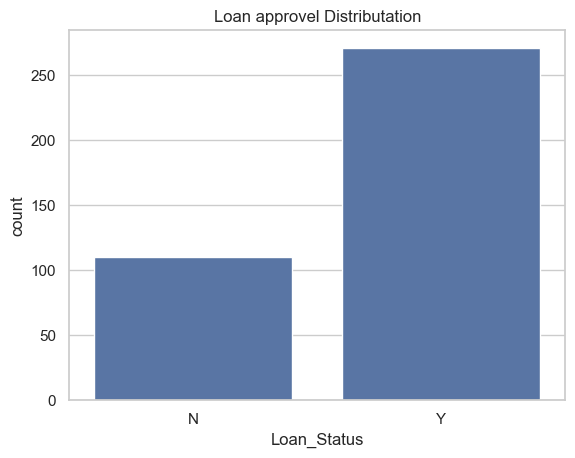

In [93]:
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan approvel Distributation')
plt.show()

In [138]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [133]:
df.duplicated().sum()


np.int64(0)

# removing the Missing or emtpy data's from cat_col and num_col for good accuracy

In [135]:
cat_col = df.select_dtypes(include='object').columns

for col in cat_col:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\happy\AppData\Local\Temp\ipykernel_7348\3861742869.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [137]:
num_col = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_col:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\happy\AppData\Local\Temp\ipykernel_7348\1328315774.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [139]:
df.isnull().sum().sum()

np.int64(0)

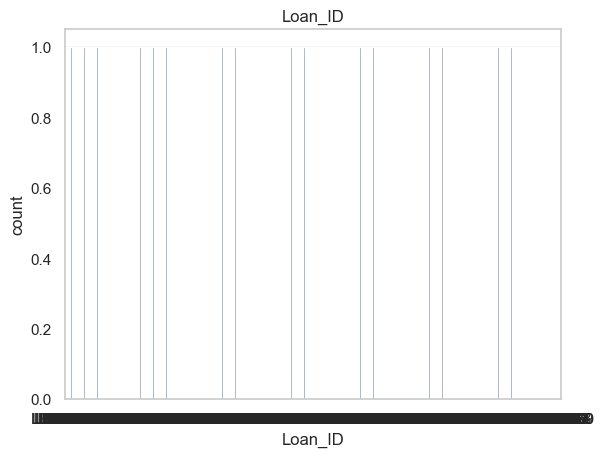

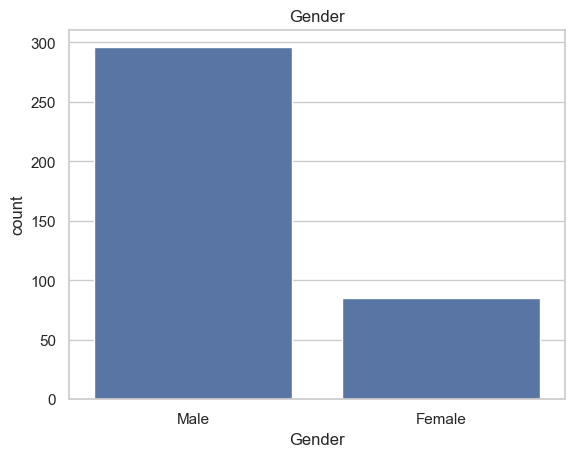

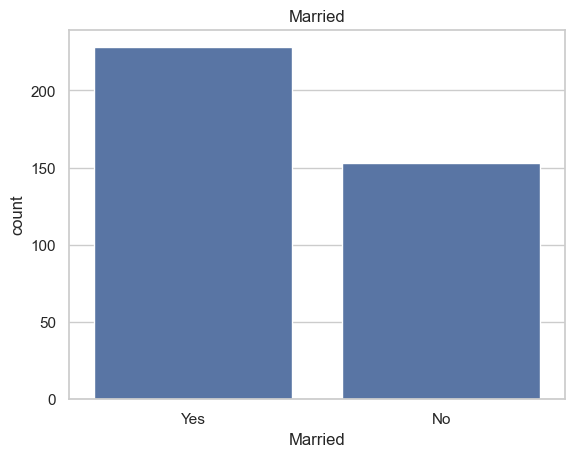

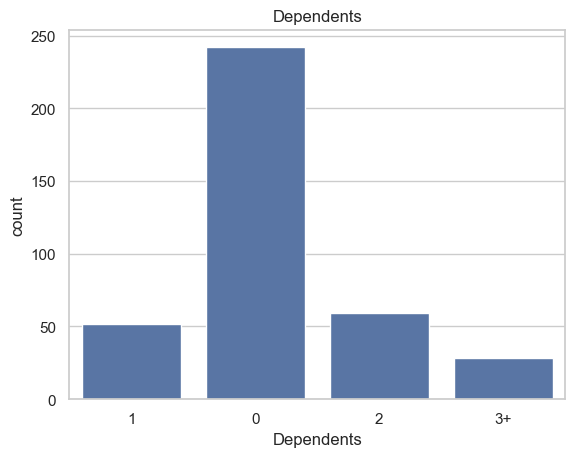

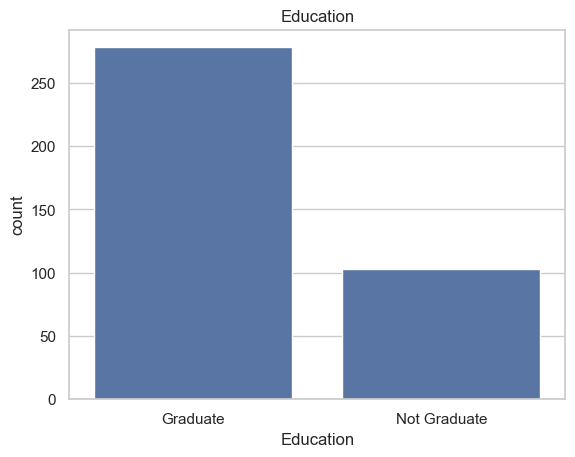

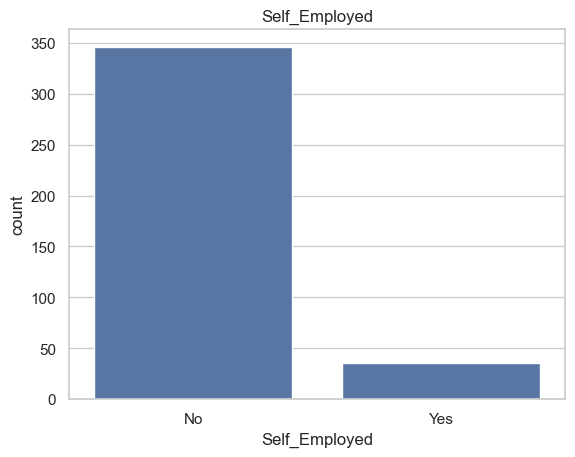

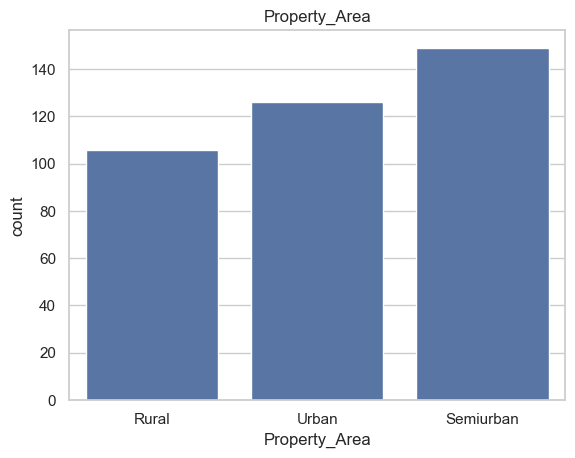

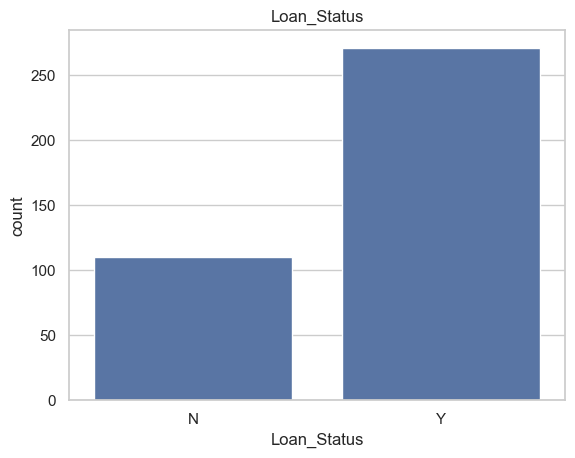

In [140]:
for col in cat_col:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

In [141]:
df[num_col].describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,381.000000,381.000000
mean,3579.845144,1277.275381,104.986877,341.417323,0.850394
std,1419.813818,2340.818114,28.358464,67.625957,0.357154
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


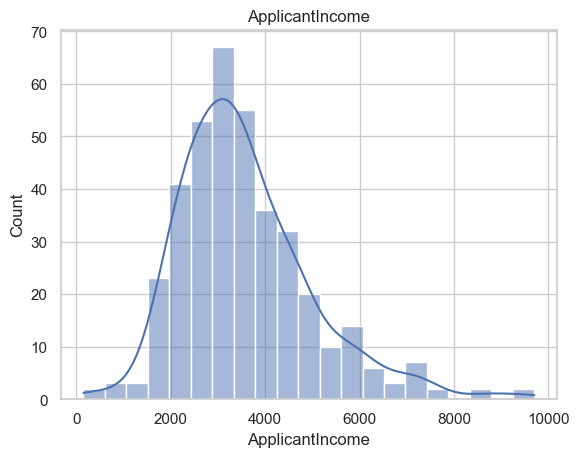

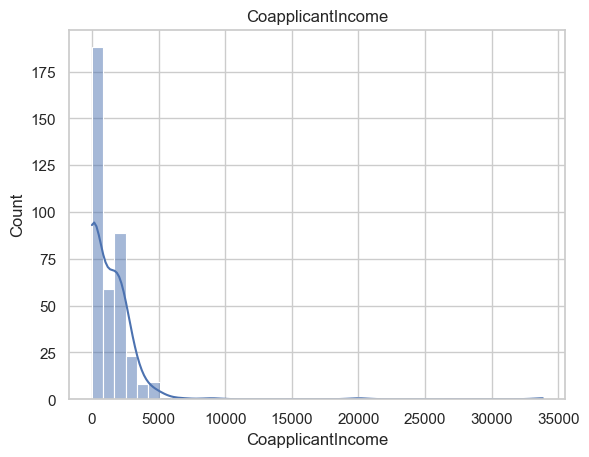

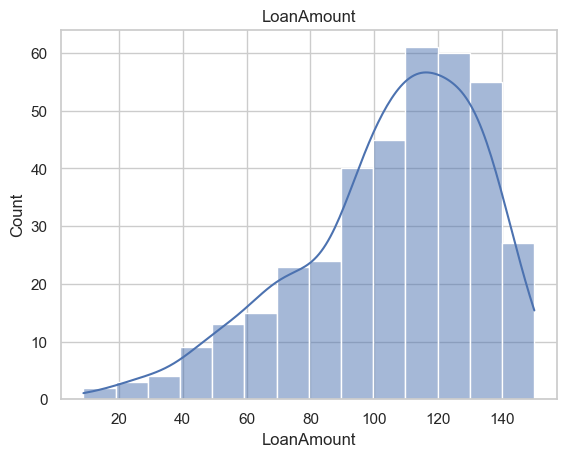

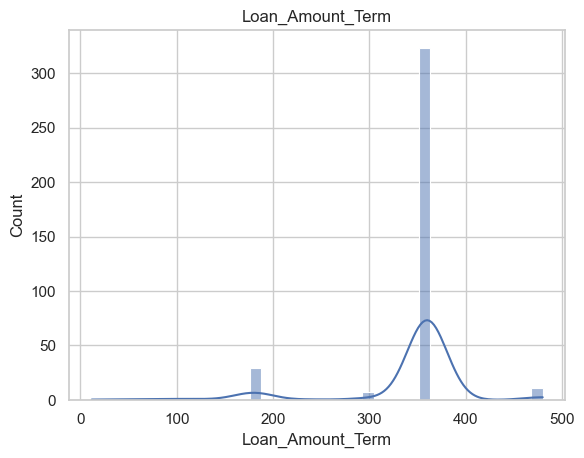

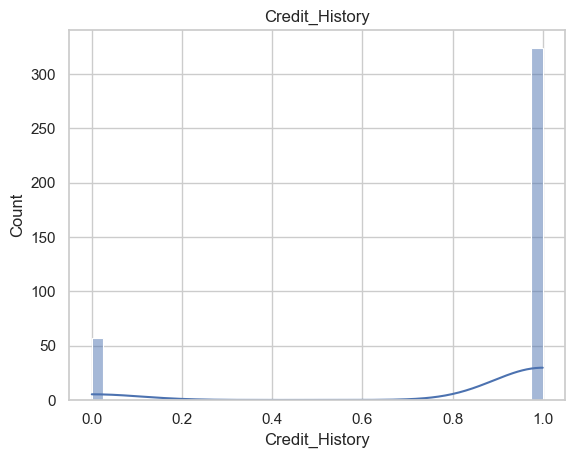

In [142]:
for col in num_col:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

BIVARIATE ANALYSIS (FEATURE vs LOAN STATUS)💟

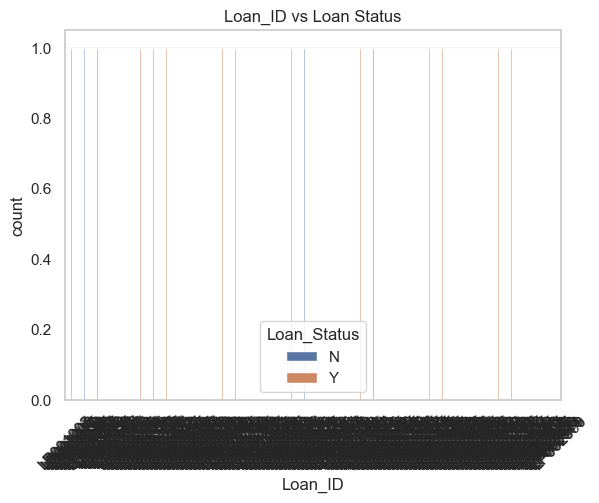

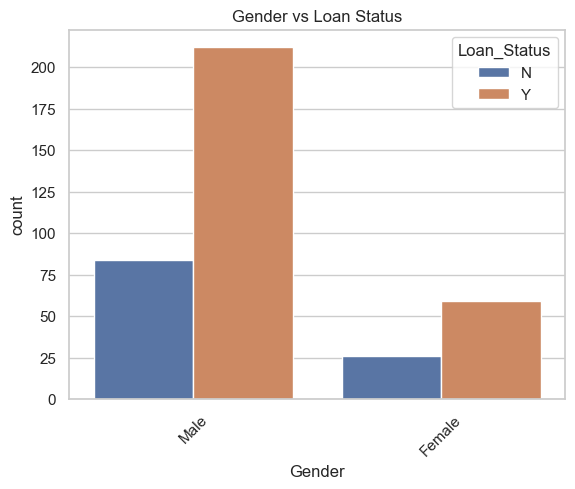

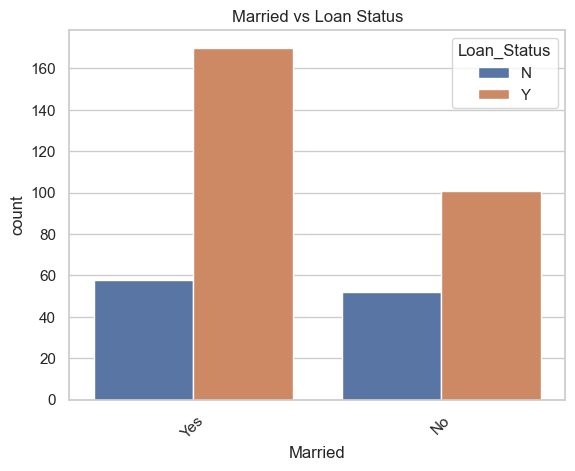

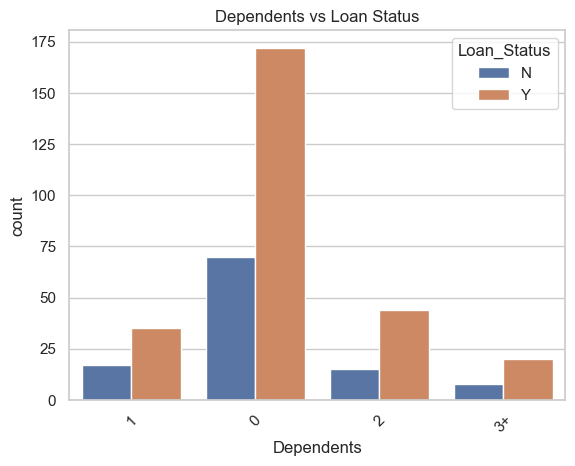

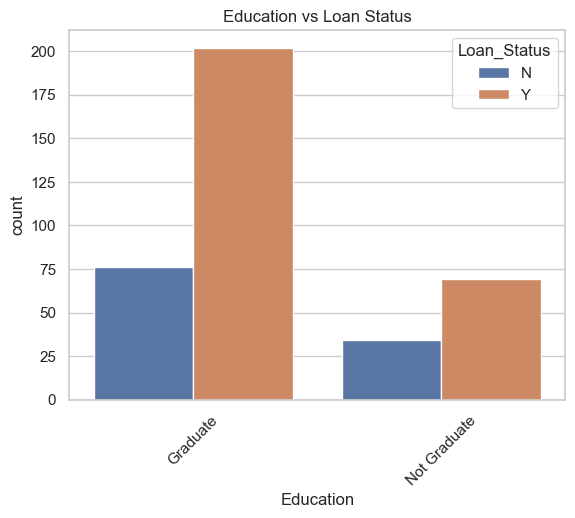

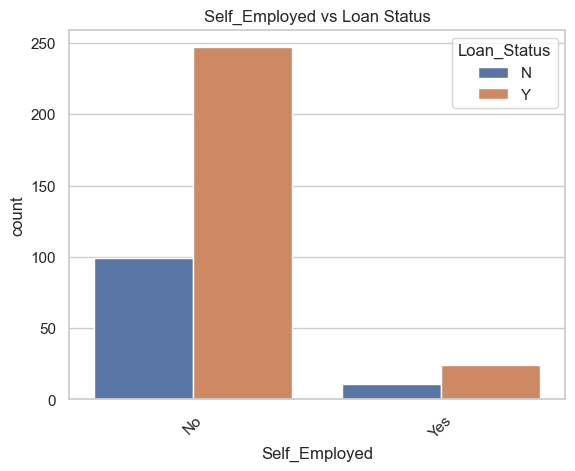

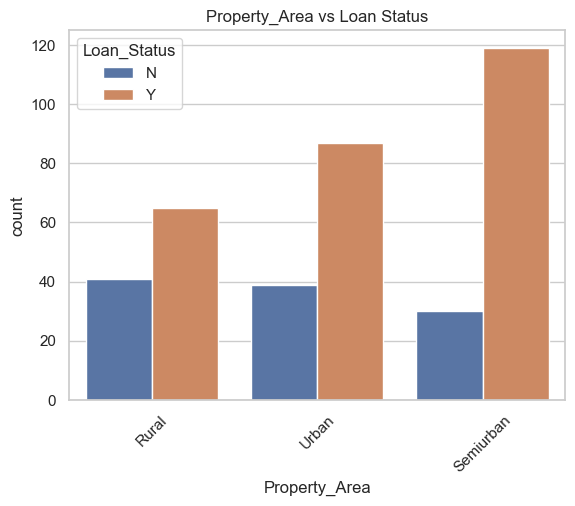

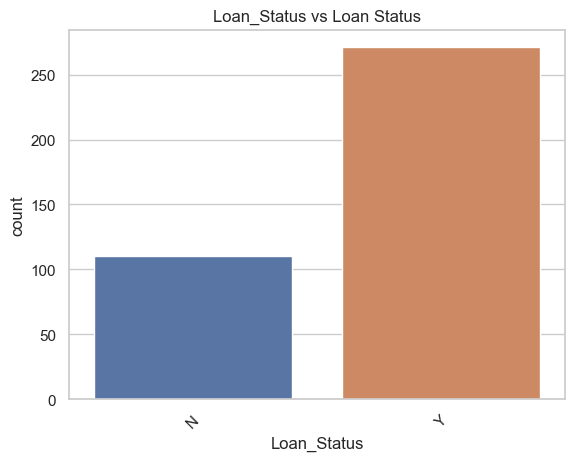

In [143]:
for col in cat_col:
    if col !='Loan_Stataus':
        sns.countplot(x=col, hue='Loan_Status', data=df)
        plt.title(f"{col} vs Loan Status")
        plt.xticks(rotation=45)
        plt.show()

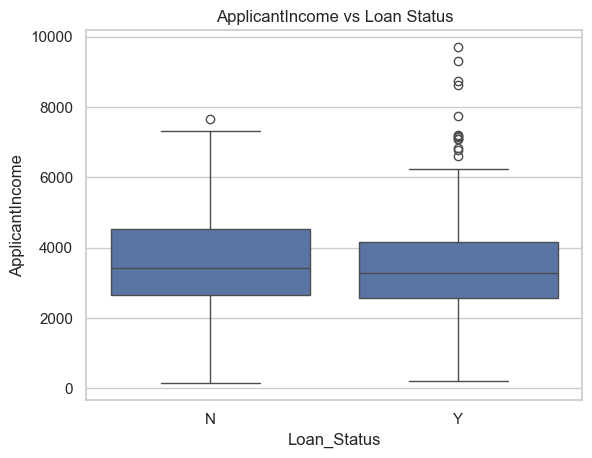

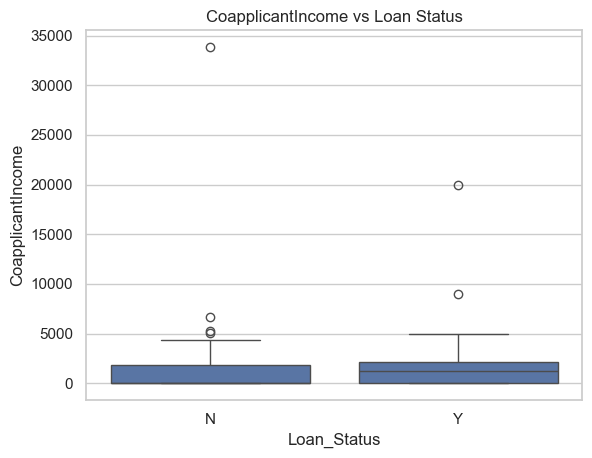

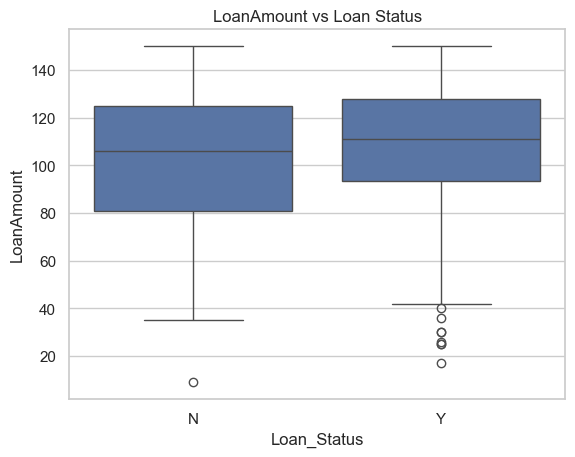

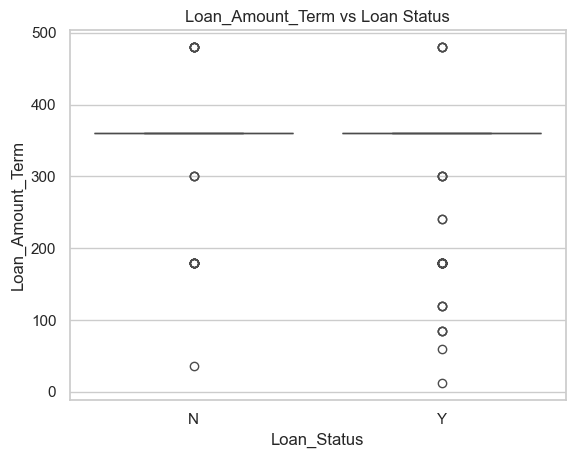

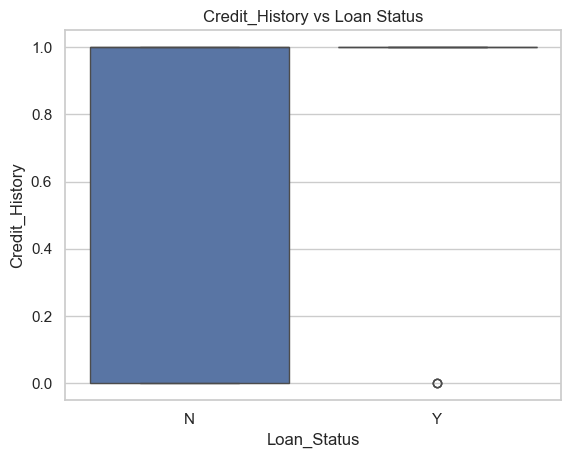

In [144]:
for col in num_col:
    sns.boxplot(x='Loan_Status', y=col, data=df)
    plt.title(f"{col} vs Loan Status")
    plt.show()


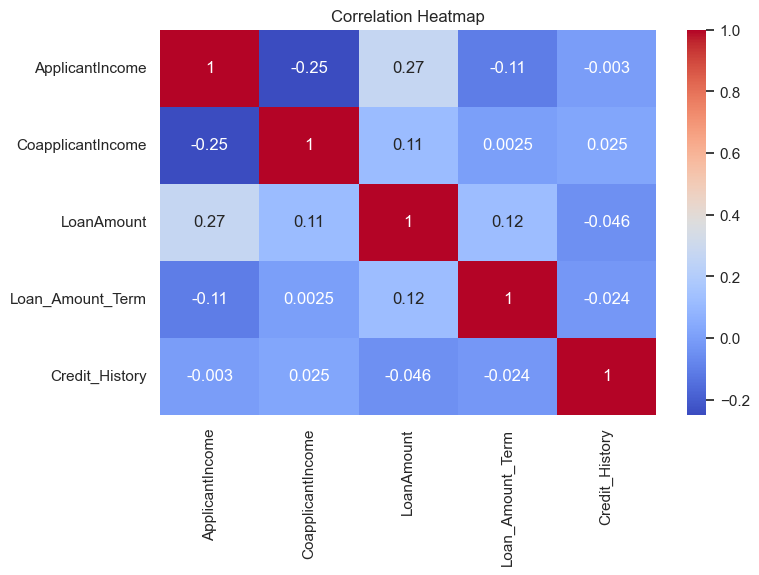

In [145]:
plt.figure(figsize=(8,5))
sns.heatmap(df[num_col].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


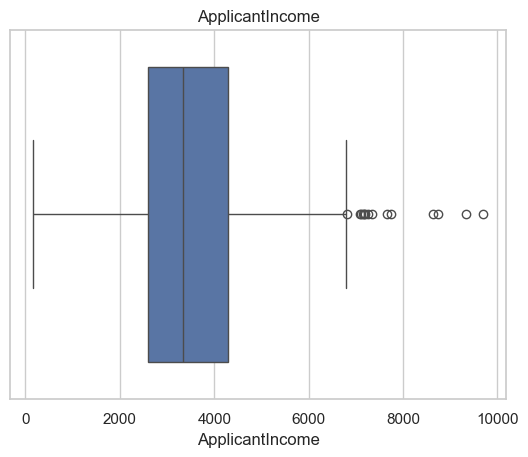

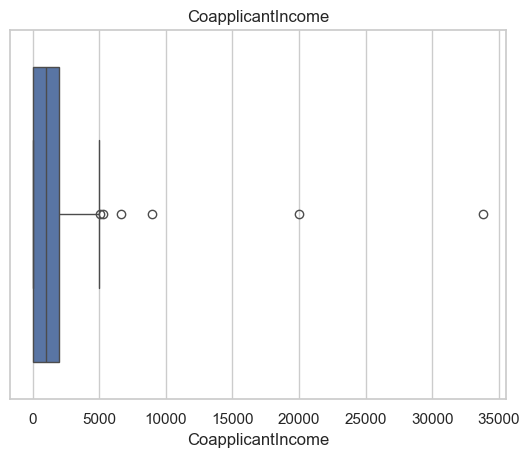

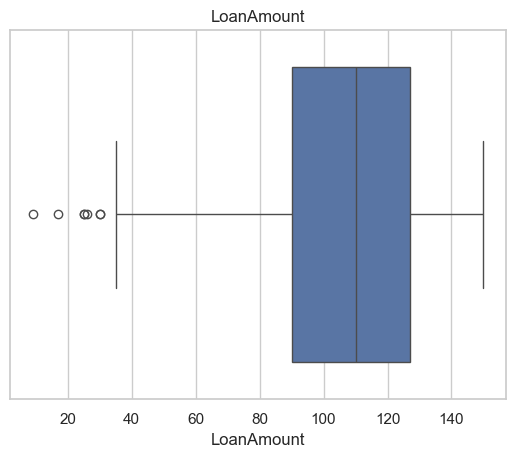

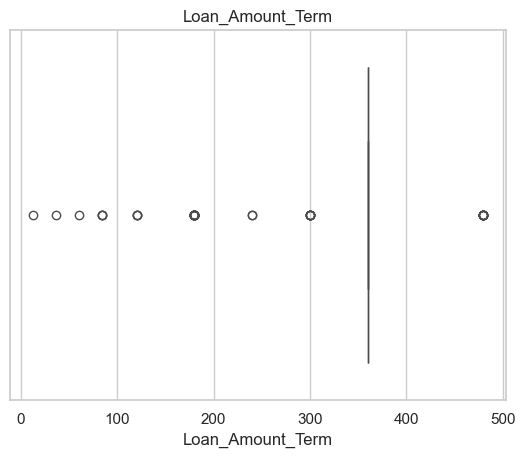

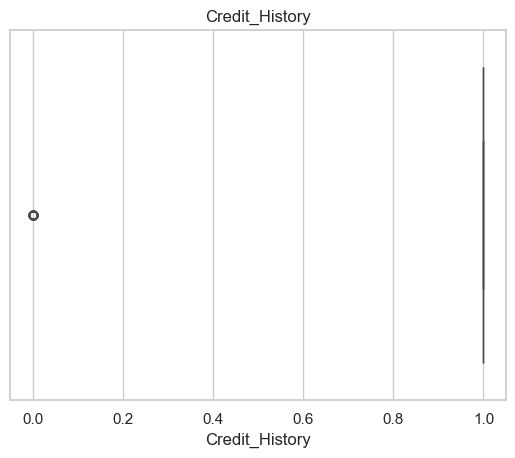

In [146]:
for col in num_col:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


# STEP 10: FEATURE ENGINEERING (EDA → ML BRIDGE)

In [147]:
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

In [148]:
df = df.drop('Loan_ID', axis=1)


In [149]:
df_encoded = pd.get_dummies(df, drop_first=True)


In [150]:
df_encoded.isnull().sum().sum()


np.int64(0)

# Key EDA Insights

Credit history is the strongest approval factor

Higher applicant income improves approval chances

Education has limited impact compared to credit history

Property area shows moderate influence

Loan amount alone does not decide approval

# Baseline Logistic Regression

In [151]:
X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']


In [152]:
print(X)


     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               4583             1508.0       128.0             360.0   
1               3000                0.0        66.0             360.0   
2               2583             2358.0       120.0             360.0   
3               6000                0.0       141.0             360.0   
4               2333             1516.0        95.0             360.0   
..               ...                ...         ...               ...   
376             5703                0.0       128.0             360.0   
377             3232             1950.0       108.0             360.0   
378             2900                0.0        71.0             360.0   
379             4106                0.0        40.0             180.0   
380             4583                0.0       133.0             360.0   

     Credit_History  Gender_Male  Married_Yes  Dependents_1  Dependents_2  \
0               1.0         True         True 

In [153]:
print(y)

0      0
1      1
2      1
3      1
4      1
      ..
376    1
377    1
378    1
379    1
380    0
Name: Loan_Status, Length: 381, dtype: int64


In [154]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)


In [155]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled  = scalar.transform(x_test)

In [156]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [157]:
y_predict = log_model.predict(x_test_scaled)

In [159]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_predict))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_predict))
print("\nClassification Report:\n", classification_report(y_test, y_predict))


Accuracy: 0.8571428571428571

Confusion Matrix:
 [[11 11]
 [ 0 55]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67        22
           1       0.83      1.00      0.91        55

    accuracy                           0.86        77
   macro avg       0.92      0.75      0.79        77
weighted avg       0.88      0.86      0.84        77



In [ ]:
coefficients = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

coefficients.head(10)


Credit_History             1.584677
Property_Area_Semiurban    0.443859
LoanAmount                 0.383211
Married_Yes                0.238542
Property_Area_Urban        0.098871
Gender_Male                0.061564
Dependents_2               0.007381
Dependents_3+             -0.074758
Self_Employed_Yes         -0.104049
CoapplicantIncome         -0.126779
dtype: float64

# this impact more on loan approval's 
Credit history is the strongest driver of loan approval.
Property area (semiurban) shows a moderate positive impact.
Loan amount contributes positively when supported by income and credit profile.
Credit_History             1.584677

Property_Area_Semiurban    0.443859

LoanAmount                 0.383211

Married_Yes                0.238542

# Baseline Logistic Regression Summary

Model trained as baseline after full EDA

Achieved reasonable performance without tuning

Credit history and income are strongest predictors

Confirms EDA observations

Next step: try tree-based models for non-linearity